In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

In [2]:
data = pd.read_csv('Model 1.csv', encoding='latin-1')

In [3]:
data

,Age,BMI,Previous Complications,Preexisting Diabetes,BP,Blood Sugar,Heart Rate,Risk Level
0,22,18.0,1,1,1,1,High,High
1,22,20.4,0,0,0,0,Normal,Low
2,27,23.0,1,0,0,0,Normal,Low
3,20,21.2,0,0,0,0,Normal,Low
4,20,19.7,0,0,0,0,Normal,Low
...,...,...,...,...,...,...,...,...
965,20,17.8,0,1,0,0,High,High
966,21,17.8,0,1,0,0,High,High
967,28,17.8,0,1,1,0,High,High
968,30,17.8,0,1,0,1,High,High


<Axes: >

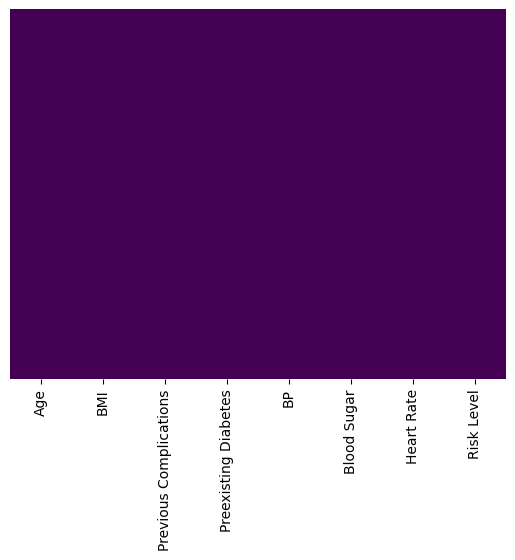

In [4]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [5]:
data.isnull().sum()

Age                       0
BMI                       0
Previous Complications    0
Preexisting Diabetes      0
BP                        0
Blood Sugar               0
Heart Rate                0
Risk Level                0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     970 non-null    int64  
 1   BMI                     970 non-null    float64
 2   Previous Complications  970 non-null    int64  
 3   Preexisting Diabetes    970 non-null    int64  
 4   BP                      970 non-null    int64  
 5   Blood Sugar             970 non-null    int64  
 6   Heart Rate              970 non-null    object 
 7   Risk Level              970 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 60.8+ KB


In [7]:
data

,Age,BMI,Previous Complications,Preexisting Diabetes,BP,Blood Sugar,Heart Rate,Risk Level
0,22,18.0,1,1,1,1,High,High
1,22,20.4,0,0,0,0,Normal,Low
2,27,23.0,1,0,0,0,Normal,Low
3,20,21.2,0,0,0,0,Normal,Low
4,20,19.7,0,0,0,0,Normal,Low
...,...,...,...,...,...,...,...,...
965,20,17.8,0,1,0,0,High,High
966,21,17.8,0,1,0,0,High,High
967,28,17.8,0,1,1,0,High,High
968,30,17.8,0,1,0,1,High,High


In [12]:
data['Heart Rate'].value_counts()

Heart Rate
Normal    637
2         261
3          72
Name: count, dtype: int64

In [13]:
data['Heart Rate'] = data['Heart Rate'].str.replace('Normal', '1', regex=False)
data['Heart Rate'] = data['Heart Rate'].str.replace('High', '2', regex=False)
data['Heart Rate'] = data['Heart Rate'].str.replace('Low', '3', regex=False)

In [14]:
data['Heart Rate'] = data['Heart Rate'].apply(np.int64)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     970 non-null    int64  
 1   BMI                     970 non-null    float64
 2   Previous Complications  970 non-null    int64  
 3   Preexisting Diabetes    970 non-null    int64  
 4   BP                      970 non-null    int64  
 5   Blood Sugar             970 non-null    int64  
 6   Heart Rate              970 non-null    int64  
 7   Risk Level              970 non-null    object 
dtypes: float64(1), int64(6), object(1)
memory usage: 60.8+ KB


In [16]:
data.describe()

,Age,BMI,Previous Complications,Preexisting Diabetes,BP,Blood Sugar,Heart Rate
count,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000
mean,27.758763,23.378247,0.189691,0.264948,0.295876,0.194845,1.417526
std,12.981433,4.057028,0.392259,0.441533,0.456671,0.396286,0.626144
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,20.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,26.000000,23.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,32.000000,25.700000,0.000000,1.000000,1.000000,0.000000,2.000000
max,325.000000,37.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [17]:
X = data[['Age','BMI','Previous Complications','Preexisting Diabetes','BP','Blood Sugar','Heart Rate']]
y = data[['Risk Level']]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [19]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
predictions = clf.predict(X_test)

In [21]:
predictions

array(['High', 'Low', 'High', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'High', 'High', 'Low', 'High', 'Low', 'High', 'Low', 'Low', 'High',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'High', 'Low', 'High',
       'High', 'Low', 'High', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'High', 'Low', 'Low', 'Low', 'High', 'Low', 'High',
       'High', 'Low', 'Low', 'High', 'Low', 'High', 'Low', 'Low', 'Low',
       'Low', 'High', 'Low', 'Low', 'Low', 'Low', 'High', 'High', 'High',
       'High', 'Low', 'Low', 'High', 'Low', 'Low', 'Low', 'Low', 'Low',
       'High', 'Low', 'High', 'High', 'High', 'Low', 'Low', 'High',
       'High', 'Low', 'Low', 'Low', 'Low', 'Low', 'High', 'High', 'Low',
       'High', 'Low', 'Low', 'Low', 'Low', 'Low', 'High', 'High', 'High',
       'High', 'High', 'Low', 'Low', 'Low', 'High', 'Low', 'High', 'Low',
       'High', 'Low', 'Low', 'High', 'Low', 'Low', 'Low', 

In [28]:
print("Risk Accuracy:", accuracy_score(y_test, predictions))

Risk Accuracy: 0.9621993127147767


In [31]:
y_test

,Risk Level
155,High
41,Low
182,High
432,Low
386,Low
...,...
733,High
401,Low
221,Low
367,Low


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


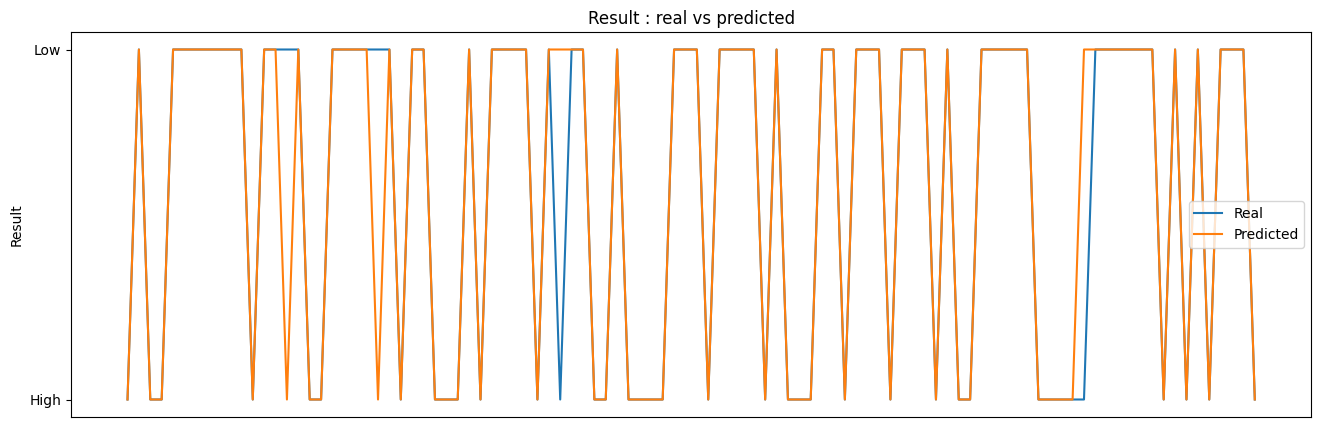

In [32]:
A = np.array(y_test).reshape(-1)
B = predictions.reshape(-1)
print(type(predictions))
print(type(y_test))
plt.rcParams['figure.figsize'] = 16,5
plt.figure()
plt.plot(A[-100:], label="Real")
plt.plot(B[-100:], label="Predicted")
plt.legend()
plt.title("Result : real vs predicted")
plt.ylabel("Result")
plt.xticks(())
plt.show()

In [22]:
pickle.dump(clf, open("model.dat", "wb"))

In [23]:
with open('model.dat' , 'rb') as f:
    model = pickle.load(f)

In [24]:
X

,Age,BMI,Previous Complications,Preexisting Diabetes,BP,Blood Sugar,Heart Rate
0,22,18.0,1,1,1,1,2
1,22,20.4,0,0,0,0,1
2,27,23.0,1,0,0,0,1
3,20,21.2,0,0,0,0,1
4,20,19.7,0,0,0,0,1
...,...,...,...,...,...,...,...
965,20,17.8,0,1,0,0,2
966,21,17.8,0,1,0,0,2
967,28,17.8,0,1,1,0,2
968,30,17.8,0,1,0,1,2


In [27]:
model.predict([[22,24.0,0,0,0,0,1]])[0]

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


'Low'